In [1]:
import warnings
warnings.filterwarnings('ignore')

In [16]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import random

In [3]:
dataset_path = "dataset"
classes = ["Islanding", "Non_Islanding"]

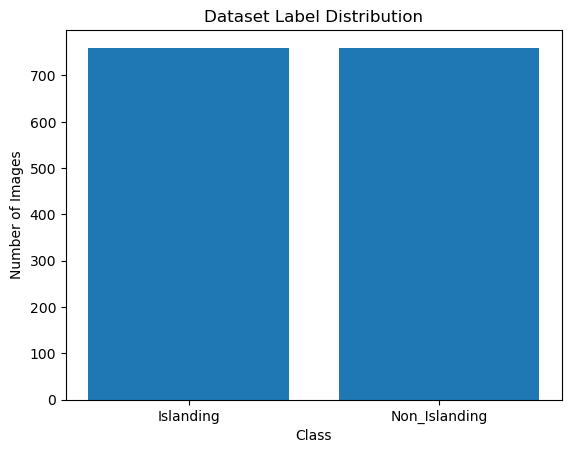

In [4]:
counts = []

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    num_images = len([f for f in os.listdir(folder) if f.endswith(".png")])
    counts.append(num_images)

plt.figure()
plt.bar(classes, counts)
plt.title("Dataset Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [5]:
print("Class distribution:")
for cls, count in zip(classes, counts):
    print(f"{cls}: {count} images")

Class distribution:
Islanding: 760 images
Non_Islanding: 760 images


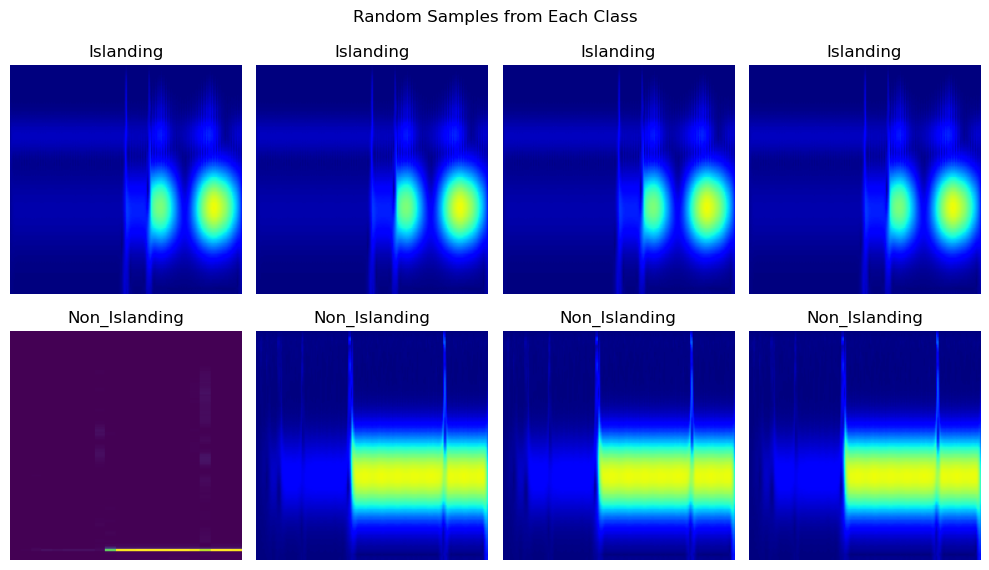

In [6]:
plt.figure(figsize=(10,6))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(folder) if f.endswith(".png")]

    random_images = random.sample(images, 4)

    for j, img_name in enumerate(random_images):

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2,4, i*4 + j + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.suptitle("Random Samples from Each Class")
plt.tight_layout()
plt.show()

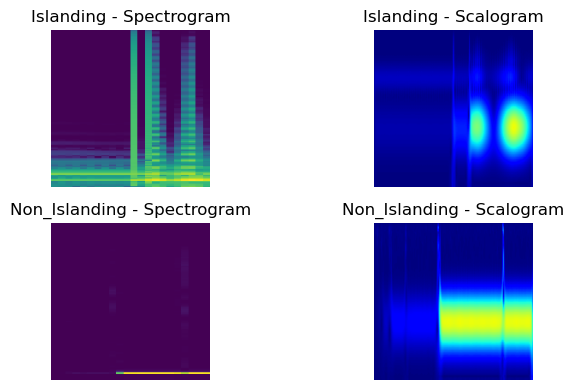

In [7]:
plt.figure(figsize=(8,4))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(folder) if f.endswith("spectrogram.png")]

    sample = random.choice(images)

    # Spectrogram
    spec_path = os.path.join(folder, sample)
    spec_img = cv2.imread(spec_path)
    spec_img = cv2.cvtColor(spec_img, cv2.COLOR_BGR2RGB)

    # Corresponding scalogram
    scalo_name = sample.replace("spectrogram", "scalogram")
    scalo_path = os.path.join(folder, scalo_name)
    scalo_img = cv2.imread(scalo_path)
    scalo_img = cv2.cvtColor(scalo_img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i*2+1)
    plt.imshow(spec_img)
    plt.title(f"{cls} - Spectrogram")
    plt.axis("off")

    plt.subplot(2,2,i*2+2)
    plt.imshow(scalo_img)
    plt.title(f"{cls} - Scalogram")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
X = []
y = []

for label, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)

    for file in tqdm(os.listdir(folder)):
        if file.endswith(".png"):

            img_path = os.path.join(folder, file)

            # Load image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (128, 128))

            # HOG feature extraction
            features = hog(img,
                           orientations=9,
                           pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2),
                           block_norm='L2-Hys')

            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 760/760 [00:19<00:00, 39.24it/s]


Feature shape: (1520, 8100)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix

In [10]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import joblib

# Save to a file
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.30, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1064, 8100), (1064,), (456, 8100), (456,))

# SVM

In [13]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train, y_train)

y_pred = svm_rbf.predict(X_test)

In [14]:
svm_acc = accuracy_score(y_pred, y_test)
svm_prec = precision_score(y_pred, y_test,average='weighted')
svm_rec = recall_score(y_pred, y_test,average='weighted')
svm_f1 = f1_score(y_pred, y_test,average='macro')

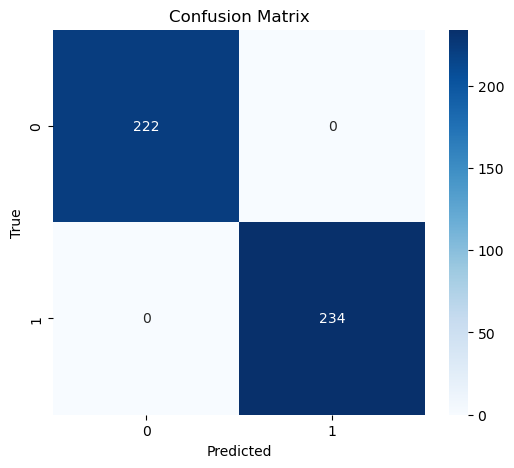

In [17]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
storeResults('SVM',svm_acc,svm_prec,svm_rec,svm_f1)

# Naive Bayes

In [19]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

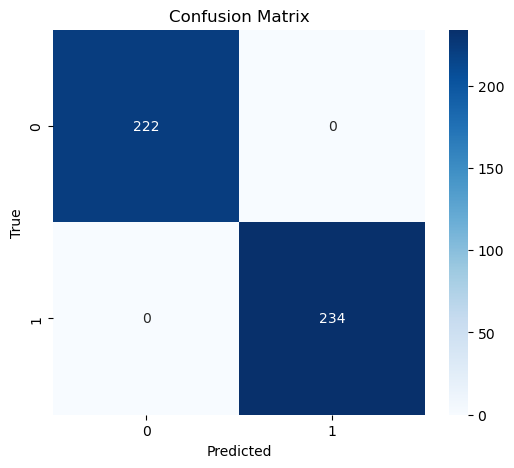

In [20]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [21]:
gnb_acc = accuracy_score(y_pred, y_test)
gnb_prec = precision_score(y_pred, y_test,average='weighted')
gnb_rec = recall_score(y_pred, y_test,average='weighted')
gnb_f1 = f1_score(y_pred, y_test,average='macro')

storeResults('GNB',gnb_acc,gnb_prec,gnb_rec,gnb_f1)

# Voting Classifier

In [22]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=100,
    num_leaves=32,           
    random_state=42,
    n_jobs=-1
)

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(
        max_depth=100,
        min_samples_split=5,
        min_samples_leaf=10,
        random_state=42
    ),
    n_estimators=3,         # more bags for stability
    max_samples=0.7,
    n_jobs=-1,
    random_state=42
)

In [23]:
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=5,        
    max_depth=10,            
    min_samples_split=5,
    min_samples_leaf=10,
    max_features='sqrt',     
    class_weight='balanced', 
    n_jobs=-1,
    random_state=42
)

brf = AdaBoostClassifier(rf, algorithm="SAMME")

ext = VotingClassifier(
    estimators=[('BoostRF', brf), ('BagDT', bag), ('LightGBM', lgbm)],
    voting='soft'
)

In [24]:
ext.fit(X_train, y_train)

y_pred = ext.predict(X_test)

ext_acc = accuracy_score(y_pred, y_test)
ext_prec = precision_score(y_pred, y_test,average='weighted')
ext_rec = recall_score(y_pred, y_test,average='weighted')
ext_f1 = f1_score(y_pred, y_test,average='macro')

[LightGBM] [Info] Number of positive: 526, number of negative: 538
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.314794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 26061
[LightGBM] [Info] Number of data points in the train set: 1064, number of used features: 6510
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494361 -> initscore=-0.022557
[LightGBM] [Info] Start training from score -0.022557
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

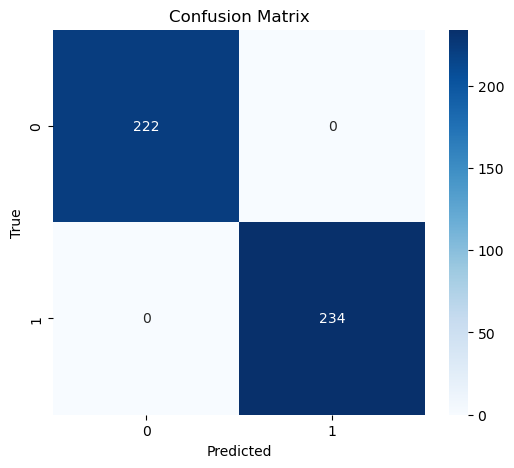

In [25]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [26]:
storeResults('Extension',ext_acc,ext_prec,ext_rec,ext_f1)

# Comparison

In [28]:
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Macro F1 score' : f1score,
                        'Recall'   : recall,
                        'Precision': precision,
                        
                      })

In [29]:
result

,ML Model,Accuracy,Macro F1 score,Recall,Precision
0,SVM,1.0,1.0,1.0,1.0
1,GNB,1.0,1.0,1.0,1.0
2,Extension,1.0,1.0,1.0,1.0


# Modelling

In [30]:
import joblib

filename = 'models/model.sav'
joblib.dump(ext, filename)

['models/model.sav']

# Graph

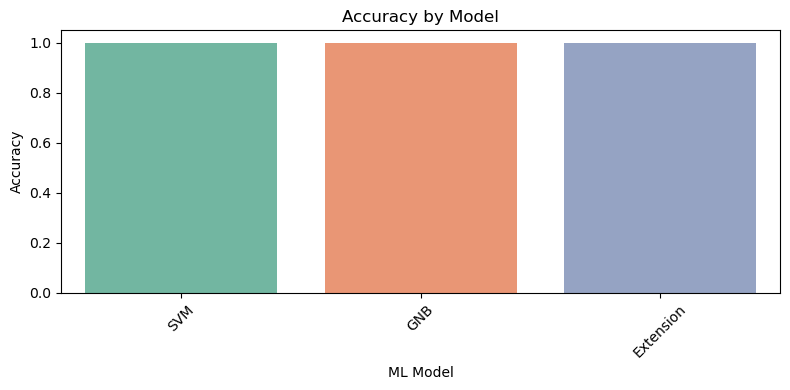

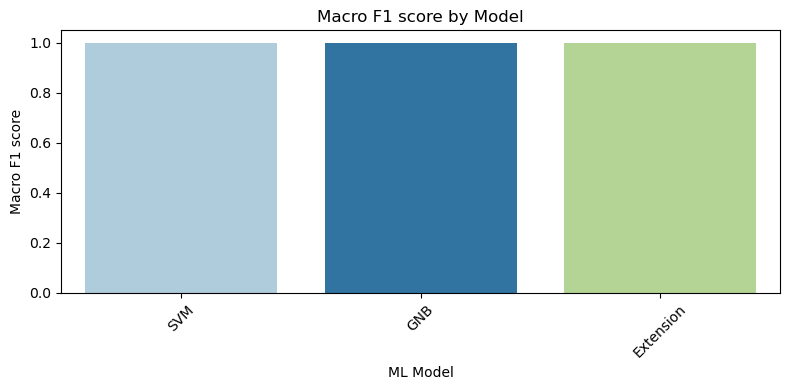

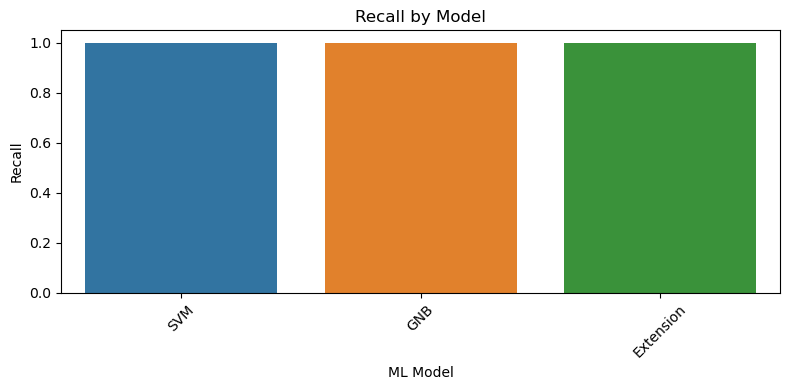

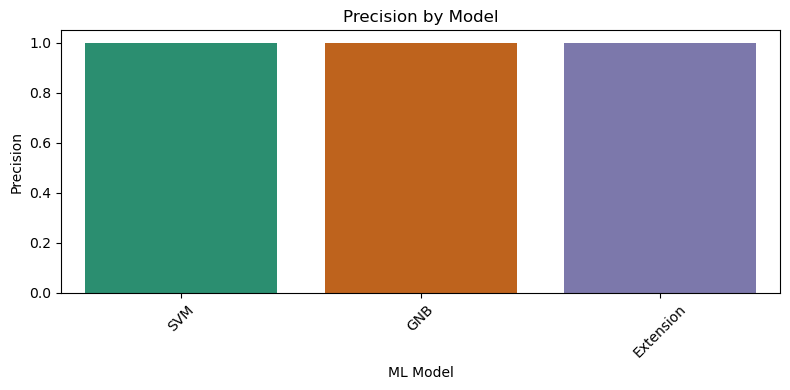

In [31]:
palettes = ['Set2', 'Paired', 'tab10', 'Dark2']

import matplotlib.pyplot as plt
import seaborn as sns

for metric, pal in zip(['Accuracy','Macro F1 score','Recall','Precision'], palettes):
    plt.figure(figsize=(8, 4))
    sns.barplot(data=result, x='ML Model', y=metric, palette=sns.color_palette(pal))
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# XAI

In [32]:
# importing lime
import lime
from lime import lime_tabular
import shap

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

In [36]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=[f"MFCC_feat_{i}" for i in range(X_train.shape[1])],
    class_names=classes,
    mode='classification'
)

In [37]:
exp = lime_explainer.explain_instance(
    X_test[0],
    ext.predict_proba,
    num_features=10
)

exp.show_in_notebook()

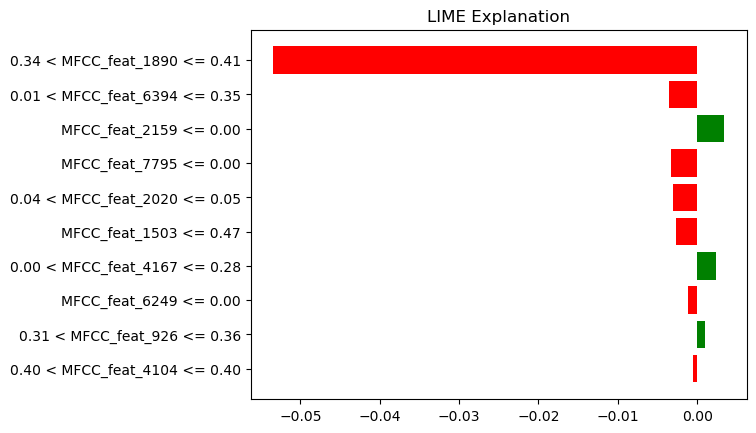

In [38]:
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation")
plt.show()

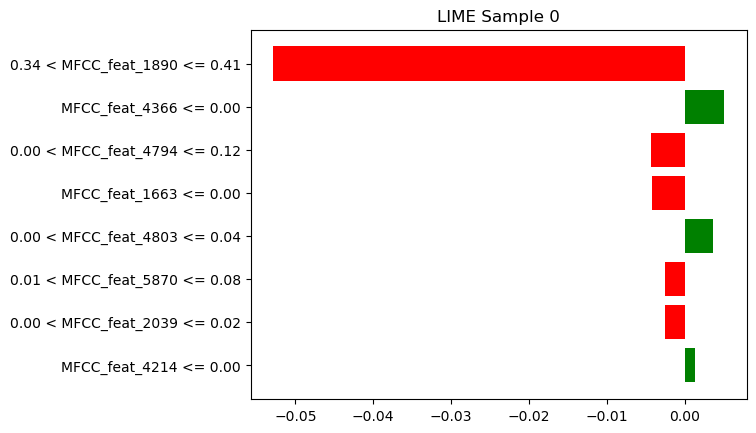

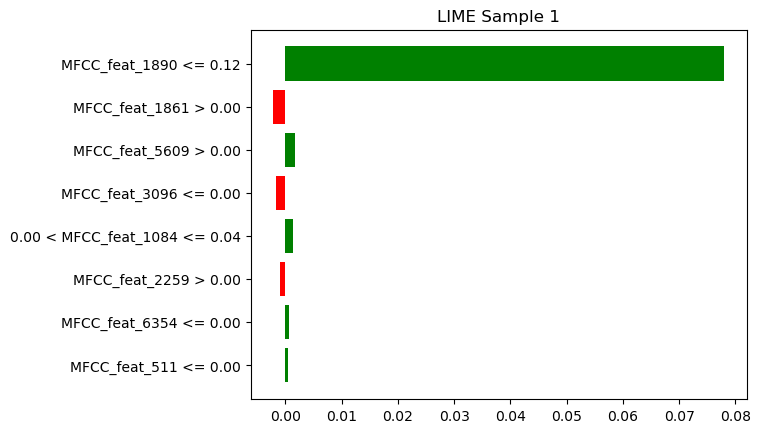

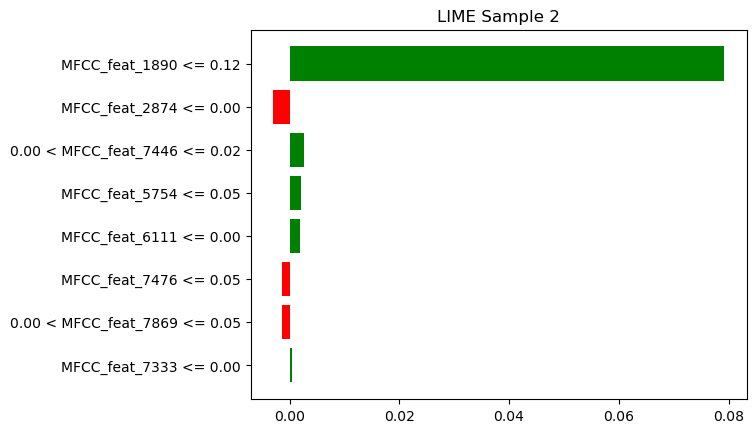

In [39]:
for i in range(3):
    exp = lime_explainer.explain_instance(
        X_test[i],
        ext.predict_proba,
        num_features=8
    )
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Sample {i}")
    plt.show()